## Understanding PyTorch Tensors

In [1]:
import torch

x = torch.arange(1, 28).reshape(3, 3, 3)
x, x.shape
# Let's index bracket by bracket
print(f"First square bracket:\n{x[0]}")
print(f"Second square bracket: {x[0][0]}")
print(f"Third square bracket: {x[0][0][0]}")

First square bracket:
tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]])
Second square bracket: tensor([1, 2, 3])
Third square bracket: 1


In [2]:
x

tensor([[[ 1,  2,  3],
         [ 4,  5,  6],
         [ 7,  8,  9]],

        [[10, 11, 12],
         [13, 14, 15],
         [16, 17, 18]],

        [[19, 20, 21],
         [22, 23, 24],
         [25, 26, 27]]])

In [3]:
x[0][1]

tensor([4, 5, 6])

In [4]:
x[:, 1]

tensor([[ 4,  5,  6],
        [13, 14, 15],
        [22, 23, 24]])

In [5]:
x[:, :, 1]

tensor([[ 2,  5,  8],
        [11, 14, 17],
        [20, 23, 26]])

In [6]:
x[:, 1, 1]

tensor([ 5, 14, 23])

### Fitting using DFNN

In [7]:
import numpy as np
import matplotlib.pyplot as plt
try:
     from dlroms import*
except:
     !pip install --no-deps git+https://github.com/NicolaRFranco/dlroms.git
     from dlroms import*

/usr/local/lib/python3.12/dist-packages/dlroms/fespaces.py:48: UserWarning: Either dolfin or fenics are not available. Some functions might not be available or work as expected.
  warnings.warn("Either dolfin or fenics are not available. Some functions might not be available or work as expected.")


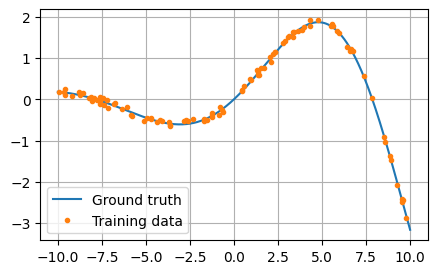

In [8]:
f =lambda x:np.sin(0.4*x)*(np.exp(x/7))

np.random.seed(0)

ndata=100
xdata=20*np.random.rand(ndata)-10
ydata=f(xdata)

noise=0.1*(2*np.random.rand(ndata)-1)
ydata +=noise

xplot=np.linspace(-10,10,1000)
yplot=f(xplot)

plt.figure(figsize=(5,3))
plt.plot(xplot,yplot,label='Ground truth')
plt.plot(xdata,ydata,'.',label='Training data')
plt.grid()
plt.legend()
plt.show()


In [9]:
xdata.shape,ydata.shape

((100,), (100,))

In [10]:
xdata=dv.tensor(xdata).unsqueeze(1)
print(xdata.shape)

torch.Size([100, 1])


In [11]:
ydata=dv.tensor(ydata).unsqueeze(1)
print(ydata.shape)


torch.Size([100, 1])


In [12]:
architecture=Dense(1,5,gelu)+Dense(5,5,gelu)+Dense(5,1,activation=None)
phi=DFNN(architecture)
phi.He() #initializzation, uses Xavier distribution for initializzation

In [13]:
import torch

def loss(y_true,y_pred):
  return (y_true-y_pred).pow(2).sum(axis=-1).mean()

phi.train(xdata,ydata,epochs=50,loss=loss,ntrain=50,nvalid=10)

		Train		Valid		Test
Epoch 42:	1.06e-03	4.83e-03	9.39e-03.

>> ETA: 1.28s.

Training complete. Elapsed time: 5.96 seconds.


In [14]:
model=phi
model.freeze()

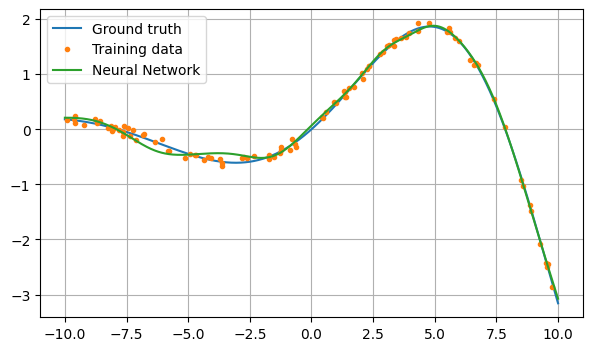

In [15]:
plt.figure(figsize = (7, 4))
plt.plot(xplot, yplot, label = 'Ground truth')

xplot = xplot.reshape(-1, 1)
plt.plot(xdata, ydata, '.', label = 'Training data')

plt.plot(xplot,model(xplot),label='Neural Network')
plt.legend()
plt.grid()
plt.show()

In [16]:
pip install pysindy==2.0.0rc3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 kB 6.8 MB/s eta 0:00:00


In [17]:
import numpy as np
import pysindy as ps

t = np.linspace(0, 1, 100)
x = 3 * np.exp(-2 * t)
y = 0.5 * np.exp(t)
X = np.stack((x, y), axis=-1)  # First column is x, second is y

model = ps.SINDy(feature_names=["x", "y"])
model.fit(X, t=t)
model.print()

(x)' = -2.000 x
(y)' = 1.000 y


# Classes in DL-ROMs

In [18]:
from dlroms.dnns import *
L = Dense(input_dim=10, output_dim=5, activation=ReLU)
# now move it to CPU (in place)
L.moveOn(core=CPU)

In [19]:
R=Dense(1,2,activation=ReLU) + Residual(dim=2,activation=ReLU)

In [20]:
R.Xavier()

In [21]:
# Model discovery

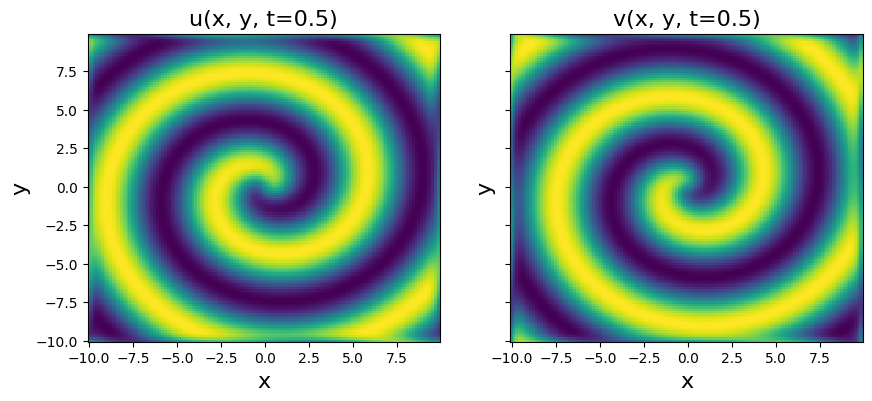

In [22]:
from numpy.fft import fft2, ifft2
from scipy.integrate import solve_ivp
#integrator_keywords['method'] = 'RK45'  # switch to RK45 integrator


# Define the reaction-diffusion PDE in the Fourier (kx, ky) space
def reaction_diffusion(t, uvt, K22, d1, d2, beta, n, N):
    ut = np.reshape(uvt[:N], (n, n))
    vt = np.reshape(uvt[N : 2 * N], (n, n))
    u = np.real(ifft2(ut))
    v = np.real(ifft2(vt))
    u3 = u ** 3
    v3 = v ** 3
    u2v = (u ** 2) * v
    uv2 = u * (v ** 2)
    utrhs = np.reshape((fft2(u - u3 - uv2 + beta * u2v + beta * v3)), (N, 1))
    vtrhs = np.reshape((fft2(v - u2v - v3 - beta * u3 - beta * uv2)), (N, 1))
    uvt_reshaped = np.reshape(uvt, (len(uvt), 1))
    uvt_updated = np.squeeze(
        np.vstack(
            (-d1 * K22 * uvt_reshaped[:N] + utrhs,
             -d2 * K22 * uvt_reshaped[N:] + vtrhs)
        )
    )
    return uvt_updated


# Generate the data
t = np.linspace(0, 10, int(10 / 0.05))
d1 = 0.1
d2 = 0.1
beta = 1.0
L = 20  # Domain size in X and Y directions
n = 128  # Number of spatial points in each direction
N = n * n
x_uniform = np.linspace(-L / 2, L / 2, n + 1)
x = x_uniform[:n]
y = x_uniform[:n]
n2 = int(n / 2)
# Define Fourier wavevectors (kx, ky)
kx = (2 * np.pi / L) * np.hstack((np.linspace(0, n2 - 1, n2),
                                  np.linspace(-n2, -1, n2)))
ky = kx
# Get 2D meshes in (x, y) and (kx, ky)
X, Y = np.meshgrid(x, y)
KX, KY = np.meshgrid(kx, ky)
K2 = KX ** 2 + KY ** 2
K22 = np.reshape(K2, (N, 1))

m = 1  # number of spirals

# define our solution vectors
u = np.zeros((len(x), len(y), len(t)))
v = np.zeros((len(x), len(y), len(t)))

# Initial conditions
u[:, :, 0] = np.tanh(np.sqrt(X ** 2 + Y ** 2)) * np.cos(
    m * np.angle(X + 1j * Y) - (np.sqrt(X ** 2 + Y ** 2))
)
v[:, :, 0] = np.tanh(np.sqrt(X ** 2 + Y ** 2)) * np.sin(
    m * np.angle(X + 1j * Y) - (np.sqrt(X ** 2 + Y ** 2))
)

# uvt is the solution vector in Fourier space, so below
# we are initializing the 2D FFT of the initial condition, uvt0
uvt0 = np.squeeze(
    np.hstack(
        (np.reshape(fft2(u[:, :, 0]), (1, N)),
         np.reshape(fft2(v[:, :, 0]), (1, N)))
    )
)

# Solve the PDE in the Fourier space, where it reduces to system of ODEs
uvsol = solve_ivp(
    reaction_diffusion, (t[0], t[-1]), y0=uvt0, t_eval=t,
    args=(K22, d1, d2, beta, n, N)
)
uvsol = uvsol.y

# Reshape things and ifft back into (x, y, t) space from (kx, ky, t) space
for j in range(len(t)):
    ut = np.reshape(uvsol[:N, j], (n, n))
    vt = np.reshape(uvsol[N:, j], (n, n))
    u[:, :, j] = np.real(ifft2(ut))
    v[:, :, j] = np.real(ifft2(vt))

# Plot to check if spiral is nicely reproduced
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.pcolor(X, Y, u[:, :, 10])
plt.xlabel('x', fontsize=16)
plt.ylabel('y', fontsize=16)
plt.title('u(x, y, t=0.5)', fontsize=16)
plt.subplot(1, 2, 2)
plt.pcolor(X, Y, v[:, :, 10])
plt.xlabel('x', fontsize=16)
plt.ylabel('y', fontsize=16)
ax = plt.gca()
ax.set_yticklabels([])
plt.title('v(x, y, t=0.5)', fontsize=16)

dt = t[1] - t[0]
dx = x[1] - x[0]
dy = y[1] - y[0]

u_sol = u
v_sol = v

In [23]:
np.shape(u)

(128, 128, 200)

In [24]:
# Compute u_t from generated solution
u = np.zeros((n, n, len(t), 2))
u[:, :, :, 0] = u_sol
u[:, :, :, 1] = v_sol
u_dot = ps.FiniteDifference(axis=2)._differentiate(u, dt)

# Choose 60 % of data for training because data is big...
# can only randomly subsample if you are passing u_dot to model.fit!!!
train = np.random.choice(len(t), int(len(t) * 0.6), replace=False)
test = [i for i in np.arange(len(t)) if i not in train]
u_train = u[:, :, train, :]
u_test = u[:, :, test, :]
u_dot_train = u_dot[:, :, train, :]
u_dot_test = u_dot[:, :, test, :]
t_train = t[train]
t_test = t[test]
spatial_grid = np.asarray([X, Y]).T

print(u_train.shape)
print(u_dot_train.shape)

(128, 128, 120, 2)
(128, 128, 120, 2)


In [38]:
# Odd polynomial terms in (u, v), up to second order derivatives in (u, v)
# library_functions = [
#     lambda x: x,
#     lambda x: x * x * x,
#     lambda x, y: x * y * y,
#     lambda x, y: x * x * y,
# ]
# library_function_names = [
#     lambda x: x,
#     lambda x: x + x + x,
#     lambda x, y: x + y + y,
#     lambda x, y: x + x + y,
# ]
pde_lib = ps.PDELibrary(
#     library_functions=library_functions,
#     function_names=library_function_names,
    function_library=ps.PolynomialLibrary(degree=3,include_bias=False),
    derivative_order=2,
    spatial_grid=spatial_grid,
    include_bias=True,
    is_uniform=True,
    periodic=True
)
print('STLSQ model: ')
optimizer = ps.STLSQ(threshold=50, alpha=1e-5,
                     normalize_columns=True, max_iter=200,verbose=True)
model = ps.SINDy(feature_library=pde_lib, optimizer=optimizer)
model.fit(u_train, x_dot=u_dot_train)
model.print()
u_dot_stlsq = model.predict(u_test)




/usr/local/lib/python3.12/dist-packages/pysindy/feature_library/pde_library.py:110: UserWarning: is_uniform and periodic have been deprecated.in favor of differetiation_method and diff_kwargs.
  warnings.warn(


STLSQ model: 
 Iteration ... |y - Xw|^2 ...  a * |w|_2 ...      |w|_0 ... Total error: |y - Xw|^2 + a * |w|_2
         0 ... 9.1422e+03 ... 3.7551e+01 ...         14 ... 9.1798e+03
         1 ... 3.9450e+03 ... 3.8186e+01 ...         14 ... 3.9832e+03
(x0)' = 0.988 x0 + -0.990 x0^3 + 0.999 x0^2 x1 + -0.990 x0 x1^2 + 1.000 x1^3 + 0.098 x0_22 + 0.097 x0_11
(x1)' = 0.988 x1 + -1.000 x0^3 + -0.989 x0^2 x1 + -0.999 x0 x1^2 + -0.990 x1^3 + 0.097 x1_22 + 0.098 x1_11


In [42]:
print('SR3 model, L1 norm: ')
optimizer = ps.SR3(
    reg_weight_lam=0.005,
        regularizer="L2",
        relax_coeff_nu=1.0e+2,
        tol=1e-5,
        trimming_fraction=0.0,
        trimming_step_size=1.0,
        max_iter=1000,
        copy_X=True,
        initial_guess=None,
        normalize_columns=False,
        verbose=True,
        unbias=False,
)
model = ps.SINDy(feature_library=pde_lib, optimizer=optimizer)
model.fit(u_train, x_dot=u_dot_train)
model.print()

SR3 model, L1 norm: 
 Iteration ... |y - Xw|^2 ...  |w-u|^2/v ...       R(u) ... Total Error: |y-Xw|^2 + |w-u|^2/v + R(u)
         0 ... 3.7808e+03 ... 2.5114e-02 ... 5.0227e-02 ... 3.7834e+03
(x0)' = 0.001 1 + 0.482 x0 + -0.028 x1 + -0.002 x0^2 + -0.002 x1^2 + -0.477 x0^3 + 0.530 x0^2 x1 + -0.475 x0 x1^2 + 0.529 x1^3 + -0.001 x0_2 + 0.001 x1_2 + 0.042 x0_22 + -0.007 x1_22 + -0.001 x1_1 + 0.002 x0_12 + -0.001 x1_12 + 0.046 x0_11 + -0.007 x1_11 + 0.005 x0x0_2 + -0.005 x1x0_2 + 0.001 x0^2x0_2 + -0.002 x0 x1x0_2 + 0.001 x1^2x0_2 + 0.005 x0^3x0_2 + 0.014 x0^2 x1x0_2 + -0.007 x0 x1^2x0_2 + 0.006 x1^3x0_2 + 0.001 x0x1_2 + 0.017 x1x1_2 + -0.001 x0^2x1_2 + -0.003 x1^2x1_2 + -0.001 x0^3x1_2 + -0.009 x0^2 x1x1_2 + 0.009 x0 x1^2x1_2 + -0.020 x1^3x1_2 + 0.002 x0x0_22 + 0.001 x1x0_22 + 0.011 x0^2x0_22 + -0.003 x0 x1x0_22 + 0.010 x1^2x0_22 + -0.002 x0^3x0_22 + -0.002 x0 x1^2x0_22 + -0.001 x1^3x0_22 + 0.002 x0x1_22 + 0.001 x1x1_22 + 0.009 x0^2x1_22 + 0.003 x0 x1x1_22 + 0.006 x1^2x1_22 + -0.002 x0^3x1

In [27]:
# Lorentz attractor

In [28]:
import warnings
from contextlib import contextmanager
from copy import copy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
from scipy.linalg import LinAlgWarning
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import Lasso

import pysindy as ps
from pysindy.utils import enzyme
from pysindy.utils import lorenz
from pysindy.utils import lorenz_control

if __name__ != "testing":
    t_end_train = 10
    t_end_test = 15
else:
    t_end_train = 0.04
    t_end_test = 0.04

data = (Path() / "../data").resolve()


@contextmanager
def ignore_specific_warnings():
    filters = copy(warnings.filters)
    warnings.filterwarnings("ignore", category=ConvergenceWarning)
    warnings.filterwarnings("ignore", category=LinAlgWarning)
    warnings.filterwarnings("ignore", category=UserWarning)
    yield
    warnings.filters = filters


if __name__ == "testing":
    import sys
    import os

    sys.stdout = open(os.devnull, "w")

In [29]:
np.random.seed(100)

integrator_keywords = {}
integrator_keywords["rtol"] = 1e-12
integrator_keywords["method"] = "LSODA"
integrator_keywords["atol"] = 1e-12

In [30]:
dt = 0.002

t_train = np.arange(0, t_end_train, dt)
x0_train = [-8, 8, 27]
t_train_span = (t_train[0], t_train[-1])
x_train = solve_ivp(
    lorenz, t_train_span, x0_train, t_eval=t_train, **integrator_keywords
).y.T

In [31]:
print(x_train[0])

[-8.  8. 27.]


In [32]:
model = ps.SINDy()
model.fit(x_train, t=dt)
model.print()

(x0)' = -9.999 x0 + 9.999 x1
(x1)' = 27.992 x0 + -0.999 x1 + -1.000 x0 x2
(x2)' = -2.666 x2 + 1.000 x0 x1


In [33]:
# concatenation

In [34]:
mat1 = torch.tensor(np.arange(1,28)).reshape(3,3,3)

mat2 = torch.tensor(np.arange(1,28)).reshape(3,3,3)

mat3 = torch.tensor(np.arange(1,28)).reshape(3,3,3)

In [35]:
A=np.concatenate((mat1,mat2,mat3),axis=0)
print(A.shape)

(9, 3, 3)


In [36]:
from scipy.io import loadmat

In [37]:
data = loadmat('data/kuramoto_sivishinky.mat')
t = np.ravel(data['tt'])
x = np.ravel(data['x'])
u = data['uu']

FileNotFoundError: [Errno 2] No such file or directory: 'data/kuramoto_sivishinky.mat'